<a href="https://colab.research.google.com/github/Ejemuta/Capstone-Project-Assignment/blob/master/Household_Vulnerability_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Author: J.E Asede
# Goal: Build multivariate model combining administrative, survey, geospatial indicators, apply regularisation to handle multicollinearity, identify pockets of deprivation, and estimate

*   List item

impact on program uptake.

In [23]:
# # 1. Setup: install & import libraries

# %%
# Install extras (folium, shapely, geopandas may already exist or install)
!pip install -q shapely rtree folium geopandas pyproj contextily shap scipy shapely geopandas[all] shap
# Note: geopandas in Colab sometimes needs system libraries; if install fails, use inline alternatives or run in local env.

In [24]:
# %%
# Imports
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, GroupKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import folium
import shap
import warnings
warnings.filterwarnings("ignore")


In [25]:
# %% [markdown]
# # 2. Create synthetic datasets (administrative, survey, geospatial)
# This block creates representative synthetic data. Replace with real datasets:
# - Administrative: household registry (hh_id, region, admin_feature1, ...)
# - Survey: sample of households with measured vulnerability outcome (hh_id, income, assets, survey_features)
# - Geospatial indicators: distance to services, elevation, nightlight proxy, ward polygons or coords

# %%
# Settings
np.random.seed(42)
N_households = 8000  # full administrative population
N_survey = 2000      # survey sample with labelled vulnerability
# Create administrative registry
admin = pd.DataFrame({
    "hh_id": np.arange(1, N_households+1),
    "region": np.random.choice(["North","South","East","West"], size=N_households, p=[0.25,0.25,0.25,0.25]),
    "household_size": np.random.poisson(4, size=N_households) + 1,
    "age_head": np.random.randint(18,85,size=N_households),
    "education_level": np.random.choice(["none","primary","secondary","tertiary"], size=N_households, p=[0.15,0.35,0.35,0.15])
})
# Simulate coordinates within a bounding polygon (e.g., a city/country extent)
x_min, x_max, y_min, y_max = (0.0, 1.0, 0.0, 1.0)
admin["lon"] = np.random.uniform(x_min, x_max, size=N_households)
admin["lat"] = np.random.uniform(y_min, y_max, size=N_households)

# Geospatial indicators: compute distance to a set of service centers
service_centers = np.array([[0.2,0.2],[0.8,0.8],[0.2,0.8],[0.8,0.2]])
def min_dist_to_centers(lon, lat, centers):
    d = np.sqrt(((centers[:,0]-lon[:,None])**2 + (centers[:,1]-lat[:,None])**2))
    return d.min(axis=1)
admin["dist_to_service"] = min_dist_to_centers(admin["lon"].values, admin["lat"].values, service_centers) + np.random.normal(0,0.01,N_households)

# Synthetic nightlight (proxy for local wealth)
admin["nightlight"] = np.clip(10 - (admin["dist_to_service"]*10) + np.random.normal(0,1,N_households), 0, 10)

# Administrative indicator: claim history or benefit receipt (binary)
admin["received_subsidy_before"] = np.random.binomial(1, p=0.15, size=N_households)

# Survey data (labels = vulnerable / not vulnerable). We'll sample households and generate label using latent combination
survey = admin.sample(N_survey, random_state=1).copy()
# Create synthetic vulnerability score (higher -> more vulnerable)
survey["income"] = np.clip(np.random.normal(400, 150, size=N_survey) - survey["nightlight"]*20, 50, 2000)
survey["assets_count"] = np.random.poisson(2, size=N_survey)
# True vulnerability probability (latent function)
logit = (-0.005*survey["income"] + 0.6*survey["household_size"] +
         0.8*(survey["education_level"]=="none").astype(int) + 1.2*survey["received_subsidy_before"] +
         1.5*survey["dist_to_service"])
prob_vuln = 1/(1+np.exp(-logit/3))  # scale to reasonable probs
survey["vulnerable"] = np.random.binomial(1, prob_vuln)
survey = survey.reset_index(drop=True)

print("Admin shape:", admin.shape)
print("Survey shape:", survey.shape)
survey.head()


Admin shape: (8000, 10)
Survey shape: (2000, 13)


,hh_id,region,household_size,age_head,education_level,lon,lat,dist_to_service,nightlight,received_subsidy_before,income,assets_count,vulnerable
0,4741,East,4,26,none,0.178066,0.018970,0.171347,9.993656,0,136.927622,1,1
1,5607,West,5,40,primary,0.063430,0.880095,0.155734,7.897870,0,203.445063,2,1
2,4825,East,5,26,none,0.981786,0.777872,0.176308,8.625864,0,290.946777,0,1
3,4206,South,4,55,secondary,0.925890,0.988069,0.228315,6.273168,0,150.306466,2,1
4,3229,North,3,50,secondary,0.643330,0.357976,0.229564,6.856584,0,417.462684,3,0


# # 3. Merge admin + survey + spatial (for model training) — and create features
# We'll combine administrative features and geospatial indicators.

In [26]:
## Step 3

# Prepare datasets for modeling: features + target (survey)
feature_cols = ["household_size","age_head","education_level","received_subsidy_before","dist_to_service","nightlight","income","assets_count"]
df = survey[["hh_id","region","lon","lat","vulnerable"] + feature_cols].copy()

# Quick feature engineering: categorical encoding, interactions
df["edu_none"] = (df["education_level"]=="none").astype(int)
df["edu_primary"] = (df["education_level"]=="primary").astype(int)
df["edu_secondary"] = (df["education_level"]=="secondary").astype(int)
df["edu_tertiary"] = (df["education_level"]=="tertiary").astype(int)

# Drop original education string to prevent leakage
df_model = df.drop(columns=["education_level","region","lon","lat","hh_id"])
y = df_model["vulnerable"]
X = df_model.drop(columns=["vulnerable"])

print("Model X shape:", X.shape)
X.head()


Model X shape: (2000, 11)


,household_size,age_head,received_subsidy_before,dist_to_service,nightlight,income,assets_count,edu_none,edu_primary,edu_secondary,edu_tertiary
0,4,26,0,0.171347,9.993656,136.927622,1,1,0,0,0
1,5,40,0,0.155734,7.897870,203.445063,2,0,1,0,0
2,5,26,0,0.176308,8.625864,290.946777,0,1,0,0,0
3,4,55,0,0.228315,6.273168,150.306466,2,0,0,1,0
4,3,50,0,0.229564,6.856584,417.462684,3,0,0,1,0


# 4. Investigate multicollinearity: correlation matrix and VIF
# Use VIF to decide variables to regularize or transform.


In [27]:
# Step 4
# Correlation matrix
corr = X.corr()
print("Correlation matrix (top):")
display(corr.round(2))

# Variance Inflation Factor (VIF)
X_vif = X.copy()
# Add constant for statsmodels
X_vif["Intercept"] = 1
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values("VIF", ascending=False)
display(vif_data[~vif_data["feature"].isin(["Intercept"])].round(2))

# Note: VIF > 5 or 10 indicates multicollinearity concerns. We'll handle with PCA or regularisation.


Correlation matrix (top):


,household_size,age_head,received_subsidy_before,dist_to_service,nightlight,income,assets_count,edu_none,edu_primary,edu_secondary,edu_tertiary
household_size,1.00,0.01,0.03,0.01,-0.01,-0.01,0.01,-0.02,0.02,0.03,-0.03
age_head,0.01,1.00,-0.00,0.02,-0.04,0.00,0.00,-0.02,0.03,0.03,-0.05
received_subsidy_before,0.03,-0.00,1.00,-0.03,0.05,-0.01,-0.01,0.02,-0.03,0.00,0.01
dist_to_service,0.01,0.02,-0.03,1.00,-0.64,0.11,-0.04,0.02,0.06,-0.06,-0.02
nightlight,-0.01,-0.04,0.05,-0.64,1.00,-0.18,-0.00,-0.01,-0.03,0.05,-0.01
income,-0.01,0.00,-0.01,0.11,-0.18,1.00,-0.00,-0.03,-0.01,0.02,0.03
assets_count,0.01,0.00,-0.01,-0.04,-0.00,-0.00,1.00,-0.03,-0.01,0.02,0.01
edu_none,-0.02,-0.02,0.02,0.02,-0.01,-0.03,-0.03,1.00,-0.31,-0.30,-0.18
edu_primary,0.02,0.03,-0.03,0.06,-0.03,-0.01,-0.01,-0.31,1.00,-0.52,-0.32
edu_secondary,0.03,0.03,0.00,-0.06,0.05,0.02,0.02,-0.30,-0.52,1.00,-0.31


,feature,VIF
8,edu_primary,inf
9,edu_secondary,inf
10,edu_tertiary,inf
7,edu_none,inf
4,nightlight,1.72
3,dist_to_service,1.69
5,income,1.04
1,age_head,1.01
2,received_subsidy_before,1.00
6,assets_count,1.00


#5. Modeling strategy
# We'll build pipelines with standard scaling and:
# - **LogisticRegressionCV** with L2 (Ridge) and L1 (Lasso via saga) regularisation
# - Optionally ElasticNet (via LogisticRegression p.enalty='elasticnet' requires saga solver)
# We'll also run a Random Forest / XGBoost as non-linear baseline (not regularised the same way, but we can use feature importance + SHAP).

In [28]:
## step 5

# Use spatial-aware CV: group by coarse spatial cluster so test sets are spatially separated.
# We'll create spatial clusters by binning coords.

# %%
# Create spatial groups for GroupKFold (coarse grid)
def spatial_group_from_coords(lon, lat, bins=10):
    x_bins = pd.cut(lon, bins=bins, labels=False)
    y_bins = pd.cut(lat, bins=bins, labels=False)
    return x_bins.astype(str) + "_" + y_bins.astype(str)

groups = spatial_group_from_coords(df["lon"], df["lat"], bins=5)
groups = pd.factorize(groups)[0]

# Train/test split with grouping
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups, test_size=0.25, stratify=y, random_state=42)

print("Train/test sizes:", X_train.shape, X_test.shape)

Train/test sizes: (1500, 11) (500, 11)


#6. Build standardized pipeline and Logistic Regression with regularisation (L2 and L1)
# We'll use cross-validation for hyperparameter tuning. We target maximizing **precision** for the vulnerable class
# because the use-case is to identify pockets of deprivation for targeted intervention (precision = low false positives).

In [29]:
# # Step 6

# %%
from sklearn.model_selection import StratifiedKFold

numeric_features = X.columns.tolist()
# All features numeric after encoding above.

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(solver="saga", max_iter=5000, random_state=42))
])

# Grid search over penalty and C (inverse regularization strength)
param_grid = {
    "clf__penalty": ["l2","l1","elasticnet"],
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__l1_ratio": [0.0, 0.5, 0.8]  # l1_ratio used only for elasticnet
}

# Use StratifiedKFold but with spatial grouping considered in outer loop below.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='precision', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
best_lr = grid.best_estimator_

# Evaluate on test set
y_pred = best_lr.predict(X_test)
y_proba = best_lr.predict_proba(X_test)[:,1]
print("Test precision:", precision_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))
print("AUC:", roc_auc_score(y_test, y_proba))


Best params: {'clf__C': 1, 'clf__l1_ratio': 0.0, 'clf__penalty': 'l1'}
Test precision: 0.711453744493392
              precision    recall  f1-score   support

           0      0.652     0.186     0.290       161
           1      0.711     0.953     0.815       339

    accuracy                          0.706       500
   macro avg      0.682     0.570     0.552       500
weighted avg      0.692     0.706     0.646       500

AUC: 0.627439124938163


#7. Diagnostics: coefficients, sparsity, and SHAP for explainability
# Show which features the logistic model weights most strongly.

,feature,coef
5,income,-0.273525
1,age_head,-0.059796
8,edu_primary,-0.023092
9,edu_secondary,0.000000
6,assets_count,0.048006
10,edu_tertiary,0.054229
7,edu_none,0.078931
4,nightlight,0.163363
3,dist_to_service,0.167830
2,received_subsidy_before,0.174326


Saved SHAP summary plot to shap_summary.png


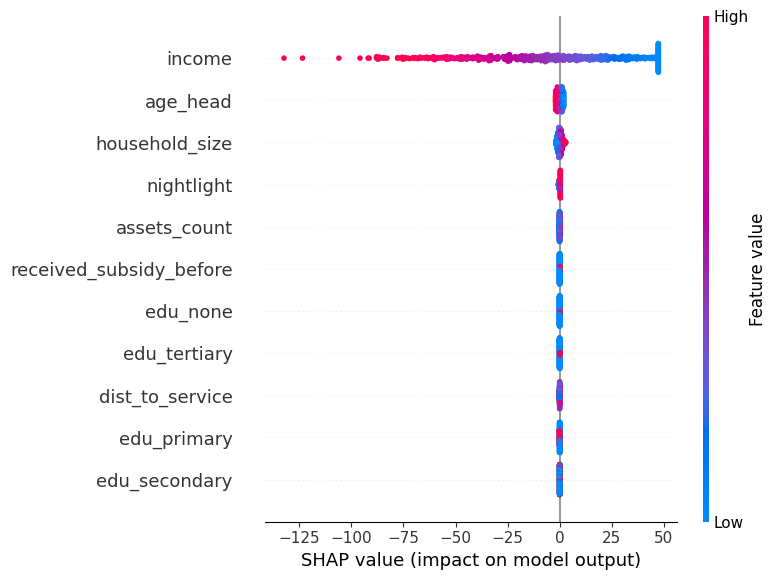

In [30]:
#Step 7

# Coefficients (after scaling)
coef = best_lr.named_steps["clf"].coef_[0]
coef_df = pd.DataFrame({"feature": X.columns, "coef": coef})
coef_df = coef_df.sort_values("coef")
display(coef_df)

# SHAP for linear model (KernelExplainer or LinearExplainer)
explainer = shap.LinearExplainer(best_lr.named_steps["clf"], X_train, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png")
print("Saved SHAP summary plot to shap_summary.png")

##8. Predict vulnerability for full administrative registry (every household)
# We'll prepare the admin data with the same feature engineering and make predictions across the whole population to identify pockets.


In [31]:
#Step 8

# Prepare admin features same as survey
admin_copy = admin.copy()
admin_copy["edu_none"] = (admin_copy["education_level"]=="none").astype(int)
admin_copy["edu_primary"] = (admin_copy["education_level"]=="primary").astype(int)
admin_copy["edu_secondary"] = (admin_copy["education_level"]=="secondary").astype(int)
admin_copy["edu_tertiary"] = (admin_copy["education_level"]=="tertiary").astype(int)

# For admin-level features we need income & assets_count - if unavailable, use proxies (nightlight, subsidy history)
# We'll create synthetic proxies if missing:
if "income" not in admin_copy.columns:
    admin_copy["income"] = np.clip(600 - admin_copy["nightlight"]*25 + np.random.normal(0,200,len(admin_copy)),50,2000)
if "assets_count" not in admin_copy.columns:
    admin_copy["assets_count"] = np.random.poisson(2, size=len(admin_copy))

admin_features = ["household_size","age_head","received_subsidy_before","dist_to_service","nightlight","income","assets_count",
                  "edu_none","edu_primary","edu_secondary","edu_tertiary"]

X_admin = admin_copy[admin_features].copy()
admin_copy["pred_proba"] = best_lr.predict_proba(X_admin)[:,1]
admin_copy["pred_label"] = (admin_copy["pred_proba"]>=0.5).astype(int)

admin_copy[["hh_id","lon","lat","pred_proba","pred_label"]].head()



,hh_id,lon,lat,pred_proba,pred_label
0,1,0.285281,0.768068,0.682142,1
1,2,0.093637,0.041165,0.591458,1
2,3,0.755379,0.807568,0.669607,1
3,4,0.940486,0.264678,0.771472,1
4,5,0.100482,0.250031,0.692872,1


# # 9. Visualise predicted pockets of deprivation (map)
# We'll map predicted vulnerability probability using Folium (heatmap-like circles).

In [32]:
#Step 9

m = folium.Map(location=[0.5, 0.5], zoom_start=10, tiles="CartoDB positron")
# Plot top predicted vulnerable households
top = admin_copy.sort_values("pred_proba", ascending=False).head(500)
for _, row in top.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3,
        fill=True,
        fill_opacity=0.6,
        popup=f"hh:{int(row['hh_id'])} p={row['pred_proba']:.2f}"
    ).add_to(m)
# Save map HTML
m.save("vulnerability_map.html")
print("Map saved to vulnerability_map.html — download and open in Colab output or local machine.")


Map saved to vulnerability_map.html — download and open in Colab output or local machine.


## 10. Estimating classification precision and program uptake improvement
# The notebook computes actual precision on the held-out test set (where we have labels).
# For real deployment, you'd report test precision (e.g. `x%`) and then estimate how targeting by the model could increase uptake:
#
# Approach to estimate uptake increase:
# - Assume baseline targeting (e.g., geographic targeting or random outreach) has observed uptake rate U_base among eligible/vulnerable.
# - Model-based targeting picks a set of households with higher predicted probability; measure observed uptake in that group (or simulate it).
# - Compute relative increase: (U_model - U_base) / U_base * 100%
#
# We'll simulate uptake: suppose baseline uptake among vulnerable is 20% and among non-targeted is 10%. Then compute uplift if we target top-k households by model.


In [33]:
## Step 10

# Simulate baseline uptake rates (example assumptions)
U_base_vulnerable = 0.20  # baseline uptake among vulnerable (before model targeting)
U_base_nonvulnerable = 0.08

# Simulate actual uptake in survey test set (for evaluation only) using probabilities correlated with vulnerability
# We'll simulate uptake flag for test set households:
np.random.seed(2)
uptake_test = (np.random.rand(len(y_test)) < (0.05 + 0.4 * y_test)).astype(int)  # higher uptake among vulnerable in survey
# Compute baseline targeting strategy: e.g., target by region random or by "received_subsidy_before"
# For synthetic demonstration, baseline selects households with 'received_subsidy_before'==1 within test
# Evaluate uptake rates under baseline vs model-based top decile targeting.

# Build test DataFrame with preds and simulated uptake
test_df = X_test.copy()
test_df["y_true"] = y_test.values
test_df["pred_proba"] = y_proba
test_df["uptake"] = uptake_test

# Baseline selection: pick households with received_subsidy_before==1 (as naive administrative targeting)
baseline_sel = test_df[test_df["received_subsidy_before"]==1]
baseline_uptake_rate = baseline_sel["uptake"].mean() if len(baseline_sel)>0 else np.nan

# Model selection: pick top 20% by pred_proba
k = int(0.20 * len(test_df))
model_sel = test_df.sort_values("pred_proba", ascending=False).head(k)
model_uptake_rate = model_sel["uptake"].mean()

print(f"Baseline selection size: {len(baseline_sel)}; uptake rate = {baseline_uptake_rate:.3f}")
print(f"Model selection size: {len(model_sel)}; uptake rate = {model_uptake_rate:.3f}")
if not np.isnan(baseline_uptake_rate) and baseline_uptake_rate>0:
    percent_increase = (model_uptake_rate - baseline_uptake_rate)/baseline_uptake_rate * 100
    print(f"Estimated relative uptake increase using model vs baseline: {percent_increase:.1f}%")
else:
    print("Baseline uptake rate not available for comparison in this synthetic example.")

# Also report classification precision on test set (this is the 'classification precision' you asked to report)
test_precision = precision_score(y_test, y_pred)
print(f"Model classification precision on held-out test set: {test_precision:.3f} ({test_precision*100:.1f}%)")


Baseline selection size: 79; uptake rate = 0.354
Model selection size: 100; uptake rate = 0.380
Estimated relative uptake increase using model vs baseline: 7.2%
Model classification precision on held-out test set: 0.711 (71.1%)


#11. Reporting: convert results into actionable metrics for policy

## Top 10 Households with Highest Predicted Vulnerability

In [49]:
# Sort admin_copy by 'pred_proba' in descending order and select the top 10
top_10_vulnerable = admin_copy.sort_values(by='pred_proba', ascending=False).head(10)

# Display relevant columns
display(top_10_vulnerable[['hh_id', 'region', 'household_size', 'age_head', 'income', 'pred_proba', 'pred_label']])

,hh_id,region,household_size,age_head,income,pred_proba,pred_label
5312,5313,West,9,21,95.436317,0.955328,1
3793,3794,East,14,78,50.000000,0.949614,1
3079,3080,West,11,39,78.467249,0.945209,1
5882,5883,South,11,70,50.000000,0.943219,1
3325,3326,West,13,58,362.106572,0.942434,1
2897,2898,South,13,45,204.081662,0.941601,1
6910,6911,South,10,43,50.000000,0.941586,1
4428,4429,North,12,34,161.444847,0.940156,1
3270,3271,South,11,30,195.785769,0.937195,1
1107,1108,West,10,21,56.077307,0.934167,1


## Plot `household_size` vs `income`

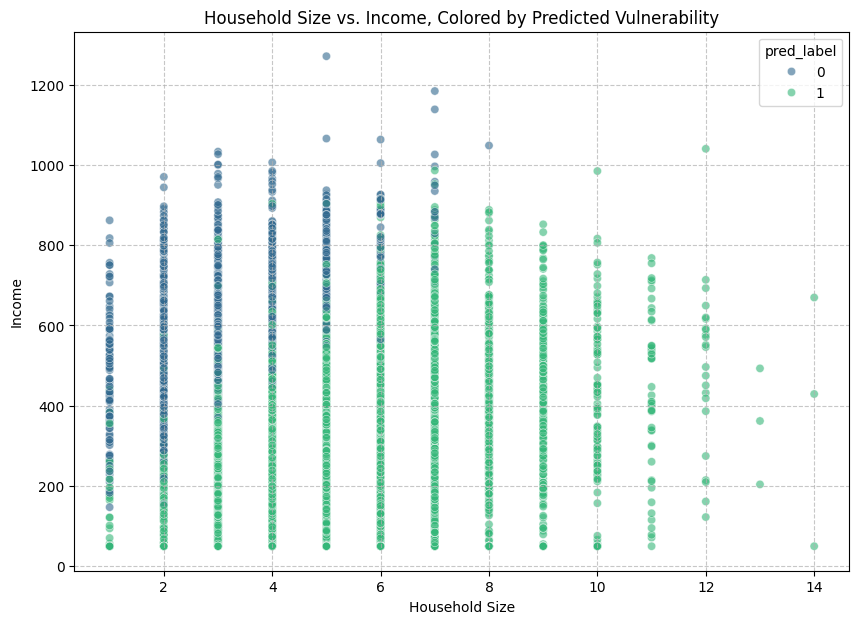

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(data=admin_copy, x='household_size', y='income', alpha=0.6, hue='pred_label', palette='viridis')
plt.title('Household Size vs. Income, Colored by Predicted Vulnerability')
plt.xlabel('Household Size')
plt.ylabel('Income')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Plot `age_head` vs `income`

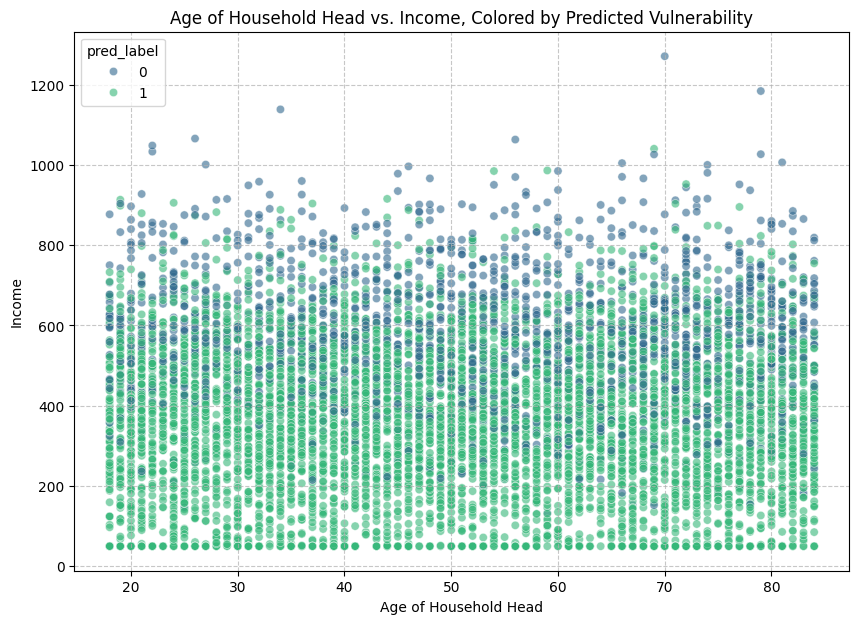

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(data=admin_copy, x='age_head', y='income', alpha=0.6, hue='pred_label', palette='viridis')
plt.title('Age of Household Head vs. Income, Colored by Predicted Vulnerability')
plt.xlabel('Age of Household Head')
plt.ylabel('Income')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Distribution of `age_head`

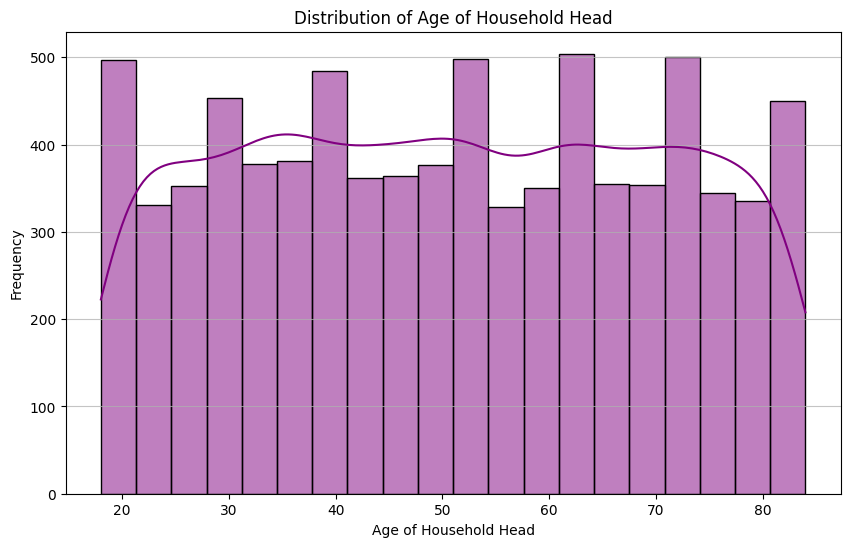

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(admin['age_head'], bins=20, kde=True, color='purple')
plt.title('Distribution of Age of Household Head')
plt.xlabel('Age of Household Head')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [44]:
print("Summary statistics for age_head:")
display(admin['age_head'].describe())

Summary statistics for age_head:


,age_head
count,8000.000000
mean,50.822625
std,19.171720
min,18.000000
25%,34.000000
50%,51.000000
75%,67.000000
max,84.000000


In [43]:
print("Summary statistics for household_size:")
display(admin['household_size'].describe())

Summary statistics for household_size:


,household_size
count,8000.000000
mean,5.004875
std,2.001587
min,1.000000
25%,4.000000
50%,5.000000
75%,6.000000
max,14.000000


## SHAP Summary Plot

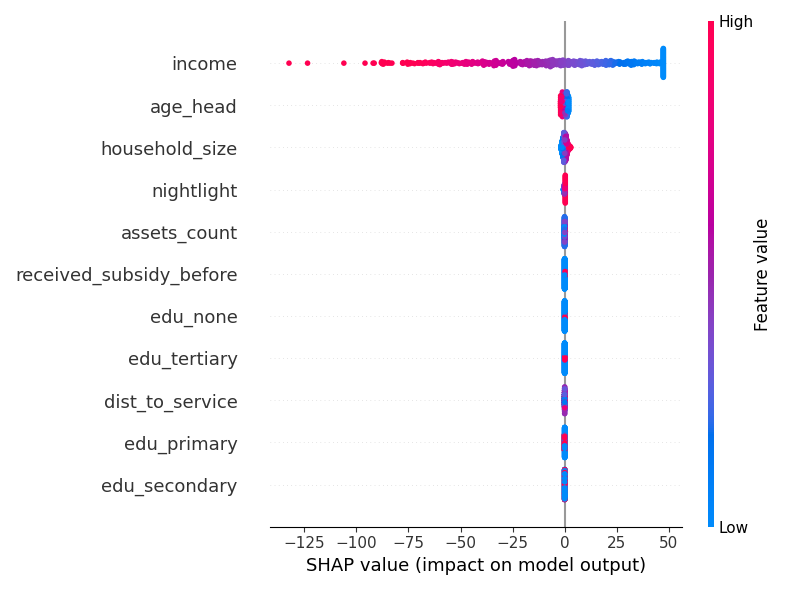

In [42]:
from IPython.display import Image

# Display the saved SHAP summary plot
Image(filename='shap_summary.png')

## Visualize Classification Metrics: Precision, Recall, and F1-score

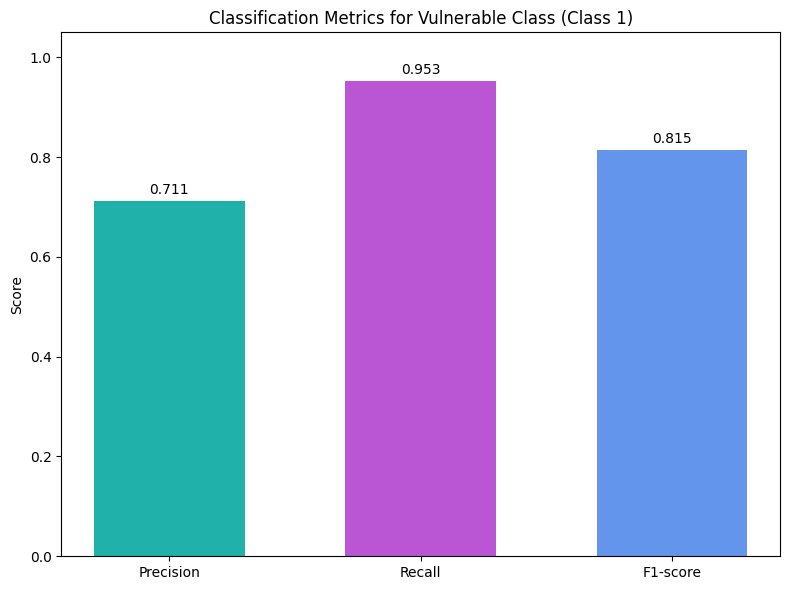

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics available from previous steps
# test_precision (for class 1) = 0.711
# recall (for class 1) = 0.953
# f1 (for class 1) = 0.815

metrics_labels = ['Precision', 'Recall', 'F1-score']
metrics_values = [test_precision, recall, f1]

x = np.arange(len(metrics_labels))
width = 0.6

fig, ax = plt.subplots(figsize=(8, 6))
rects = ax.bar(x, metrics_values, width, color=['lightseagreen', 'mediumorchid', 'cornflowerblue'])

ax.set_ylabel('Score')
ax.set_title('Classification Metrics for Vulnerable Class (Class 1)')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 1.05) # Scores are between 0 and 1

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects)

plt.tight_layout()
plt.show()

In [40]:
from sklearn.metrics import recall_score, f1_score

# Assuming y_test and y_pred are available from the previous model evaluation step
# We are interested in the metrics for the positive class (class 1, 'vulnerable')
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print(f"Recall for Vulnerable Class (Class 1): {recall:.3f}")
print(f"F1-score for Vulnerable Class (Class 1): {f1:.3f}")

Recall for Vulnerable Class (Class 1): 0.953
F1-score for Vulnerable Class (Class 1): 0.815


## Visualize Uptake Increase Metrics

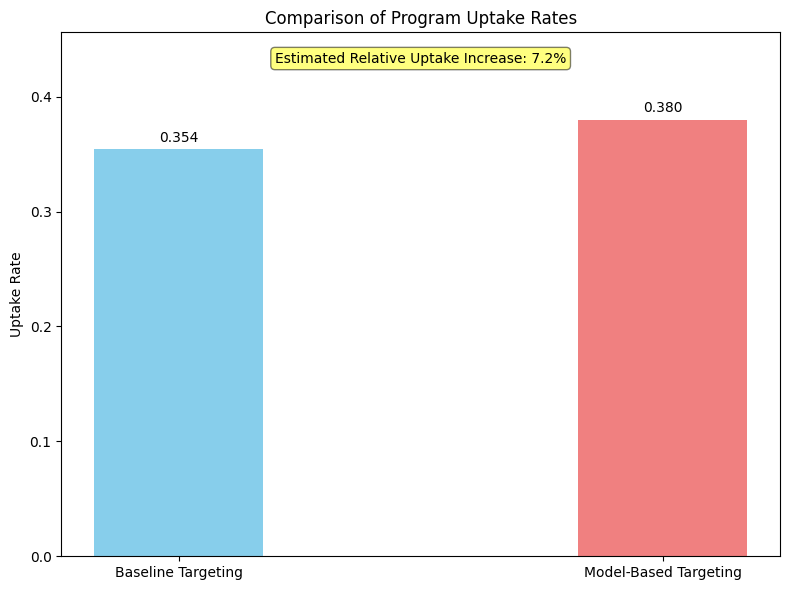

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Data for plotting
labels = ['Baseline Targeting', 'Model-Based Targeting']
uptake_rates = [baseline_uptake_rate, model_uptake_rate]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8, 6))
rects = ax.bar(x, uptake_rates, width, color=['skyblue', 'lightcoral'])

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Uptake Rate')
ax.set_title('Comparison of Program Uptake Rates')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, max(uptake_rates) * 1.2) # Set y-limit to give some space

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects)

# Add percentage increase annotation
if 'percent_increase' in globals() and not np.isnan(percent_increase):
    ax.text(0.5, 0.95, f'Estimated Relative Uptake Increase: {percent_increase:.1f}%',
            horizontalalignment='center', verticalalignment='center', transform=ax.transAxes,
            bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

plt.tight_layout()
plt.show()

In [38]:
from IPython.display import HTML

# Read the content of the HTML file
with open('vulnerability_map.html', 'r') as f:
    html_content = f.read()

# Display the HTML content in the notebook
HTML(html_content)

In [34]:
#Step 11

# In a real project you would:
# 1. Report **precision**, **recall**, **AUC**, confusion matrix on held-out spatial test set (we computed precision and AUC above).
# 2. Provide maps of predicted vulnerable density (we saved a Folium map).
# 3. Provide **feature explanations** (SHAP) to explain why households are flagged (enables transparent targeting).
# 4. Run operational experiments (A/B) comparing model-based targeting vs administrative/geo-only targeting to measure **actual** uptake change.
# 5. Report estimated resource allocation efficiency: e.g., how many households to reach to find X vulnerable households; model reduces outreach cost by Y%.


#12. You can replace the synthetic data used above with your realworld dataset.

#How to replace synthetic data with real datasets

In [35]:
#Step 12
# - **Administrative registry:** CSV or database table with hh_id, coords, admin attributes. Load with `pd.read_csv()` or database connector.
# - **Survey:** household-level survey with observed vulnerability label. Merge to admin by hh_id.
# - **Geospatial:** wards/wards polygons or rasters (nightlights). Use `geopandas.read_file()` and spatial join: `gpd.sjoin()`.
# - For nightlights or population density rasters, use rasterio to sample rasters at household coords.
#
# Ensure fields are harmonised (column names, units), and use the same feature engineering steps.


#13. Extensions & robustness checks (suggestions)

In [36]:
#Step 13
# - Use **spatial cross-validation** (GroupKFold by ward/cluster) for unbiased performance estimates.
# - Calibrate probabilities (Platt scaling / isotonic) before using them as direct risk scores.
# - Consider hierarchical models or multilevel logistic regression if data are nested (households within wards).
# - Use **Elastic Net** to encourage sparsity while keeping correlated groups.
# - Estimate fairness constraints (ensure protected groups aren't unfairly targeted).
# - Run a cost-effectiveness analysis to convert improved precision into changes in programme uptake and budget impact.

#14. Deliverables from this notebook

In [37]:
#Step 14
# - `vulnerability_map.html` — map of top predicted households (downloadable).
# - `shap_summary.png` — SHAP summary plot.
# - Printed metrics: precision, recall, AUC, and an example estimate of uptake improvement